In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score
)
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import shap
import gradio as gr

from collections import Counter
import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load Dataset
df = pd.read_excel("Disaster_Datatset.xlsx")

print("Dataset Shape:", df.shape)
print("\nAll Columns:")
print(list(df.columns))


Dataset Shape: (9730, 47)

All Columns:
['DisNo.', 'Historic', 'Classification Key', 'Disaster Group', 'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype', 'External IDs', 'Event Name', 'ISO', 'Country', 'Subregion', 'Region', 'Location', 'Origin', 'Associated Types', 'OFDA/BHA Response', 'Appeal', 'Declaration', "AID Contribution ('000 US$)", 'Magnitude', 'Magnitude Scale', 'Latitude', 'Longitude', 'River Basin', 'Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day', 'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless', 'Total Affected', "Reconstruction Costs ('000 US$)", "Reconstruction Costs, Adjusted ('000 US$)", "Insured Damage ('000 US$)", "Insured Damage, Adjusted ('000 US$)", "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)", 'CPI', 'Admin Units', 'GADM Admin Units', 'Entry Date', 'Last Update']


In [3]:
print("\n=== TARGET COLUMN: 'Disaster Type' ===")
print("All disaster types in dataset:")
print(df['Disaster Type'].value_counts())
print("Length :", len(df['Disaster Type']))


=== TARGET COLUMN: 'Disaster Type' ===
All disaster types in dataset:
Disaster Type
Flood                          4242
Storm                          2817
Earthquake                      694
Extreme temperature             568
Mass movement (wet)             496
Drought                         420
Wildfire                        338
Volcanic activity               133
Mass movement (dry)              14
Glacial lake outburst flood       8
Name: count, dtype: int64
Length : 9730


In [4]:
df.head(5)

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
0,2018-0040-BRA,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),DFO:4576,NaN,BRA,...,NaN,NaN,NaN,10000.0,12492.0,80.049596,"[{""adm2_code"":9961,""adm2_name"":""Rio De Janeiro""}]","[{""gid_2"":""BRA.19.68_2"",""migration_date"":""2025...",2018-02-20,2025-12-20
1,2002-0351-USA,No,nat-cli-wil-for,Natural,Climatological,Wildfire,Forest fire,NaN,NaN,USA,...,NaN,NaN,NaN,20000.0,34879.0,57.341840,"[{""adm1_code"":3219,""adm1_name"":""Colorado""}]","[{""gid_1"":""USA.6_1"",""migration_date"":""2025-12-...",2003-07-01,2025-12-20
2,2022-0770-RWA,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,RWA,...,NaN,NaN,NaN,NaN,NaN,93.294607,"[{""adm1_code"":21970,""adm1_name"":""Kigali City/U...","[{""gid_1"":""RWA.5_1"",""migration_date"":""2025-12-...",2022-11-25,2025-12-20
3,2024-9796-USA,No,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,NaN,NaN,USA,...,NaN,NaN,NaN,5400000.0,5400000.0,100.000000,NaN,"[{""gid_1"":""USA.13_1"",""name_1"":""Idaho""},{""gid_1...",2024-10-29,2025-12-20
4,2000-0620-NGA,No,nat-hyd-flo-fla,Natural,Hydrological,Flood,Flash flood,NaN,NaN,NGA,...,NaN,NaN,NaN,4805.0,8753.0,54.895152,"[{""adm1_code"":2230,""adm1_name"":""Lagos""}]","[{""gid_1"":""NGA.25_1"",""migration_date"":""2025-12...",2005-09-15,2025-12-20


In [5]:
# Missing Value Analysis
missing_counts = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

In [6]:
missing_df = pd.DataFrame({'Missing Count': missing_counts, 'Missing %': missing_pct})
missing_df

,Missing Count,Missing %
DisNo.,0,0.00
Historic,0,0.00
Classification Key,0,0.00
Disaster Group,0,0.00
Disaster Subgroup,0,0.00
Disaster Type,0,0.00
Disaster Subtype,0,0.00
External IDs,5711,58.69
Event Name,7892,81.11
ISO,0,0.00


In [7]:
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)


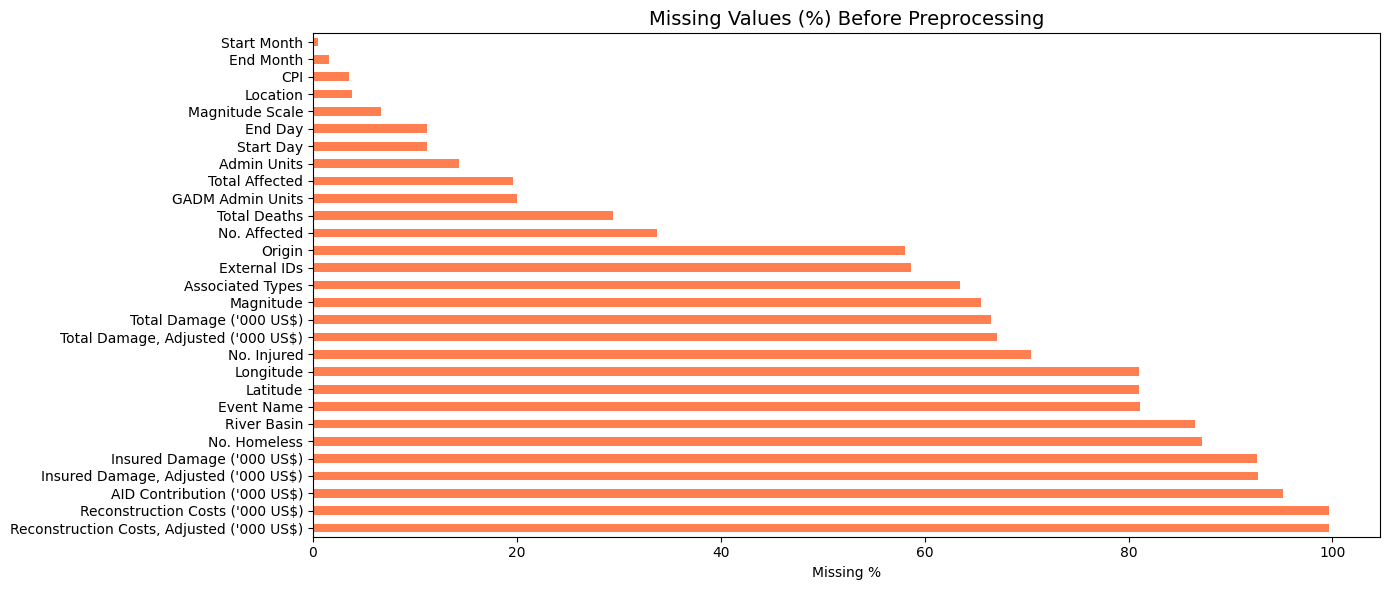

In [8]:
plt.figure(figsize=(14, 6))
missing_df['Missing %'].plot(kind='barh', color='coral')
plt.title("Missing Values (%) Before Preprocessing", fontsize=14)
plt.xlabel("Missing %")
plt.tight_layout()
plt.show() 

In [9]:
print("\nTop columns with missing data:")
print(missing_df.head(15))


Top columns with missing data:
                                           Missing Count  Missing %
Reconstruction Costs, Adjusted ('000 US$)           9699      99.68
Reconstruction Costs ('000 US$)                     9698      99.67
AID Contribution ('000 US$)                         9254      95.11
Insured Damage, Adjusted ('000 US$)                 9020      92.70
Insured Damage ('000 US$)                           9010      92.60
No. Homeless                                        8486      87.21
River Basin                                         8417      86.51
Event Name                                          7892      81.11
Latitude                                            7879      80.98
Longitude                                           7879      80.98
No. Injured                                         6849      70.39
Total Damage, Adjusted ('000 US$)                   6533      67.14
Total Damage ('000 US$)                             6469      66.49
Magnitude       

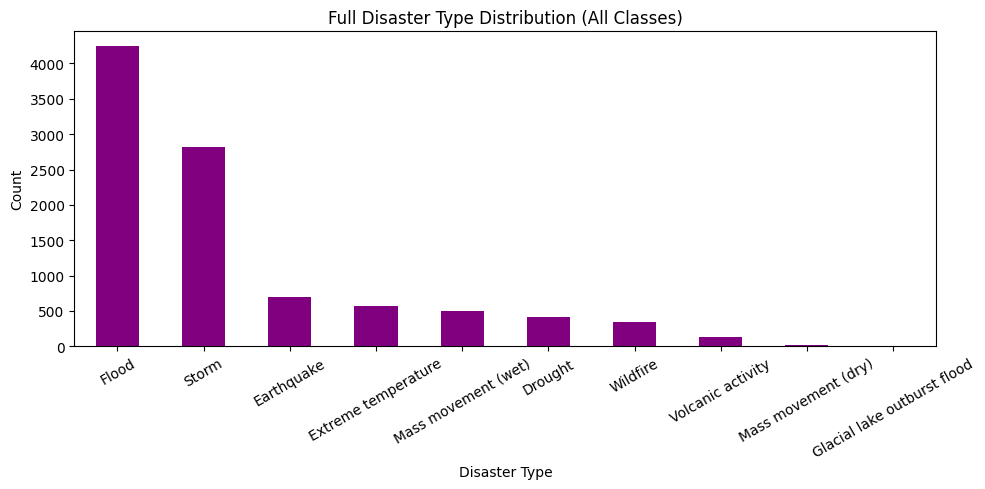

In [10]:
# Full disaster type distribution
plt.figure(figsize=(10, 5))
df['Disaster Type'].value_counts().plot(kind='bar', color='purple')
plt.title("Full Disaster Type Distribution (All Classes)")
plt.xlabel("Disaster Type")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [11]:
# Filter to 3 disaster types (as per base paper)
target_classes = ['Flood', 'Earthquake', 'Wildfire']
df_filtered = df[df['Disaster Type'].isin(target_classes)].copy()

print("Shape after filtering:", df_filtered.shape)
print("\n=== Class Distribution (3 Classes) ===")
print(df_filtered['Disaster Type'].value_counts())
print("\n>>> IMBALANCE NOTED: Flood >> Earthquake > Wildfire")

Shape after filtering: (5274, 47)

=== Class Distribution (3 Classes) ===
Disaster Type
Flood         4242
Earthquake     694
Wildfire       338
Name: count, dtype: int64

>>> IMBALANCE NOTED: Flood >> Earthquake > Wildfire


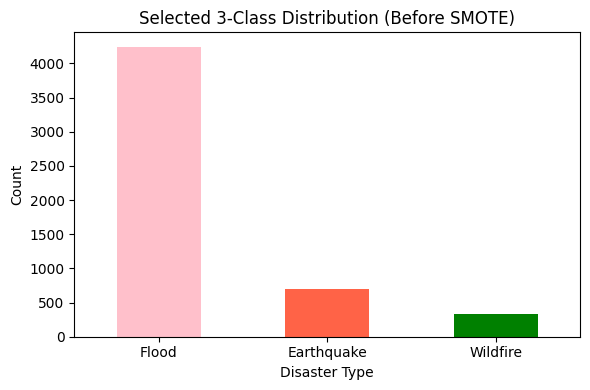

In [12]:
plt.figure(figsize=(6, 4))
df_filtered['Disaster Type'].value_counts().plot(kind='bar', color=['pink','tomato','green'])
plt.title("Selected 3-Class Distribution (Before SMOTE)")
plt.xlabel("Disaster Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
# Drop columns with >80% missing values
missing_pct_filtered = df_filtered.isnull().mean() * 100
cols_to_drop = missing_pct_filtered[missing_pct_filtered > 80].index
print("Columns dropped (>80% missing):", list(cols_to_drop))

Columns dropped (>80% missing): ['Event Name', "AID Contribution ('000 US$)", 'No. Homeless', "Reconstruction Costs ('000 US$)", "Reconstruction Costs, Adjusted ('000 US$)", "Insured Damage ('000 US$)", "Insured Damage, Adjusted ('000 US$)"]


In [14]:
df_clean = df_filtered.drop(columns=cols_to_drop).copy()
print("Shape after dropping high-missing columns:", df_clean.shape)

Shape after dropping high-missing columns: (5274, 40)


In [15]:
# Remove leakage columns (columns that directly reveal the target)
leakage_cols = ['Classification Key', 'Disaster Group', 'Disaster Subgroup', 'Disaster Subtype']
leakage_cols = [c
                for c in leakage_cols if c in df_clean.columns]
df_clean = df_clean.drop(columns=leakage_cols)
print("Removed leakage columns:", leakage_cols)
print("Shape:", df_clean.shape)

Removed leakage columns: ['Classification Key', 'Disaster Group', 'Disaster Subgroup', 'Disaster Subtype']
Shape: (5274, 36)


In [16]:
# Encode TARGET column: Disaster Type
label_encoder_target = LabelEncoder()
df_clean['Disaster Type'] = label_encoder_target.fit_transform(df_clean['Disaster Type'])

# Show the encoding mapping clearly
print("=== TARGET ENCODING ===")
for cls, code in zip(label_encoder_target.classes_, label_encoder_target.transform(label_encoder_target.classes_)):
    print(f"  {cls} --> {code}")

# Separate X and y
y = df_clean['Disaster Type']
X = df_clean.drop(columns=['Disaster Type'])

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

=== TARGET ENCODING ===
  Earthquake --> 0
  Flood --> 1
  Wildfire --> 2

Features shape: (5274, 35)
Target shape: (5274,)


In [17]:
print("\nFeature columns:")
print(list(X.columns))


Feature columns:
['DisNo.', 'Historic', 'External IDs', 'ISO', 'Country', 'Subregion', 'Region', 'Location', 'Origin', 'Associated Types', 'OFDA/BHA Response', 'Appeal', 'Declaration', 'Magnitude', 'Magnitude Scale', 'Latitude', 'Longitude', 'River Basin', 'Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day', 'Total Deaths', 'No. Injured', 'No. Affected', 'Total Affected', "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)", 'CPI', 'Admin Units', 'GADM Admin Units', 'Entry Date', 'Last Update']


In [18]:
# Encode all remaining categorical features
X_encoded = X.copy()
categorical_cols = X_encoded.select_dtypes(include=['object']).columns
print("Categorical columns to encode:", list(categorical_cols))

feature_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    feature_encoders[col] = le

print("Encoding completed.")


feature_columns = X_encoded.columns.tolist()

import pickle
with open("feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

Categorical columns to encode: ['DisNo.', 'Historic', 'External IDs', 'ISO', 'Country', 'Subregion', 'Region', 'Location', 'Origin', 'Associated Types', 'OFDA/BHA Response', 'Appeal', 'Declaration', 'Magnitude Scale', 'River Basin', 'Admin Units', 'GADM Admin Units', 'Entry Date', 'Last Update']
Encoding completed.


In [19]:
print(len(feature_columns))

35


In [20]:
print("Final feature shape:", X_encoded.shape)

Final feature shape: (5274, 35)


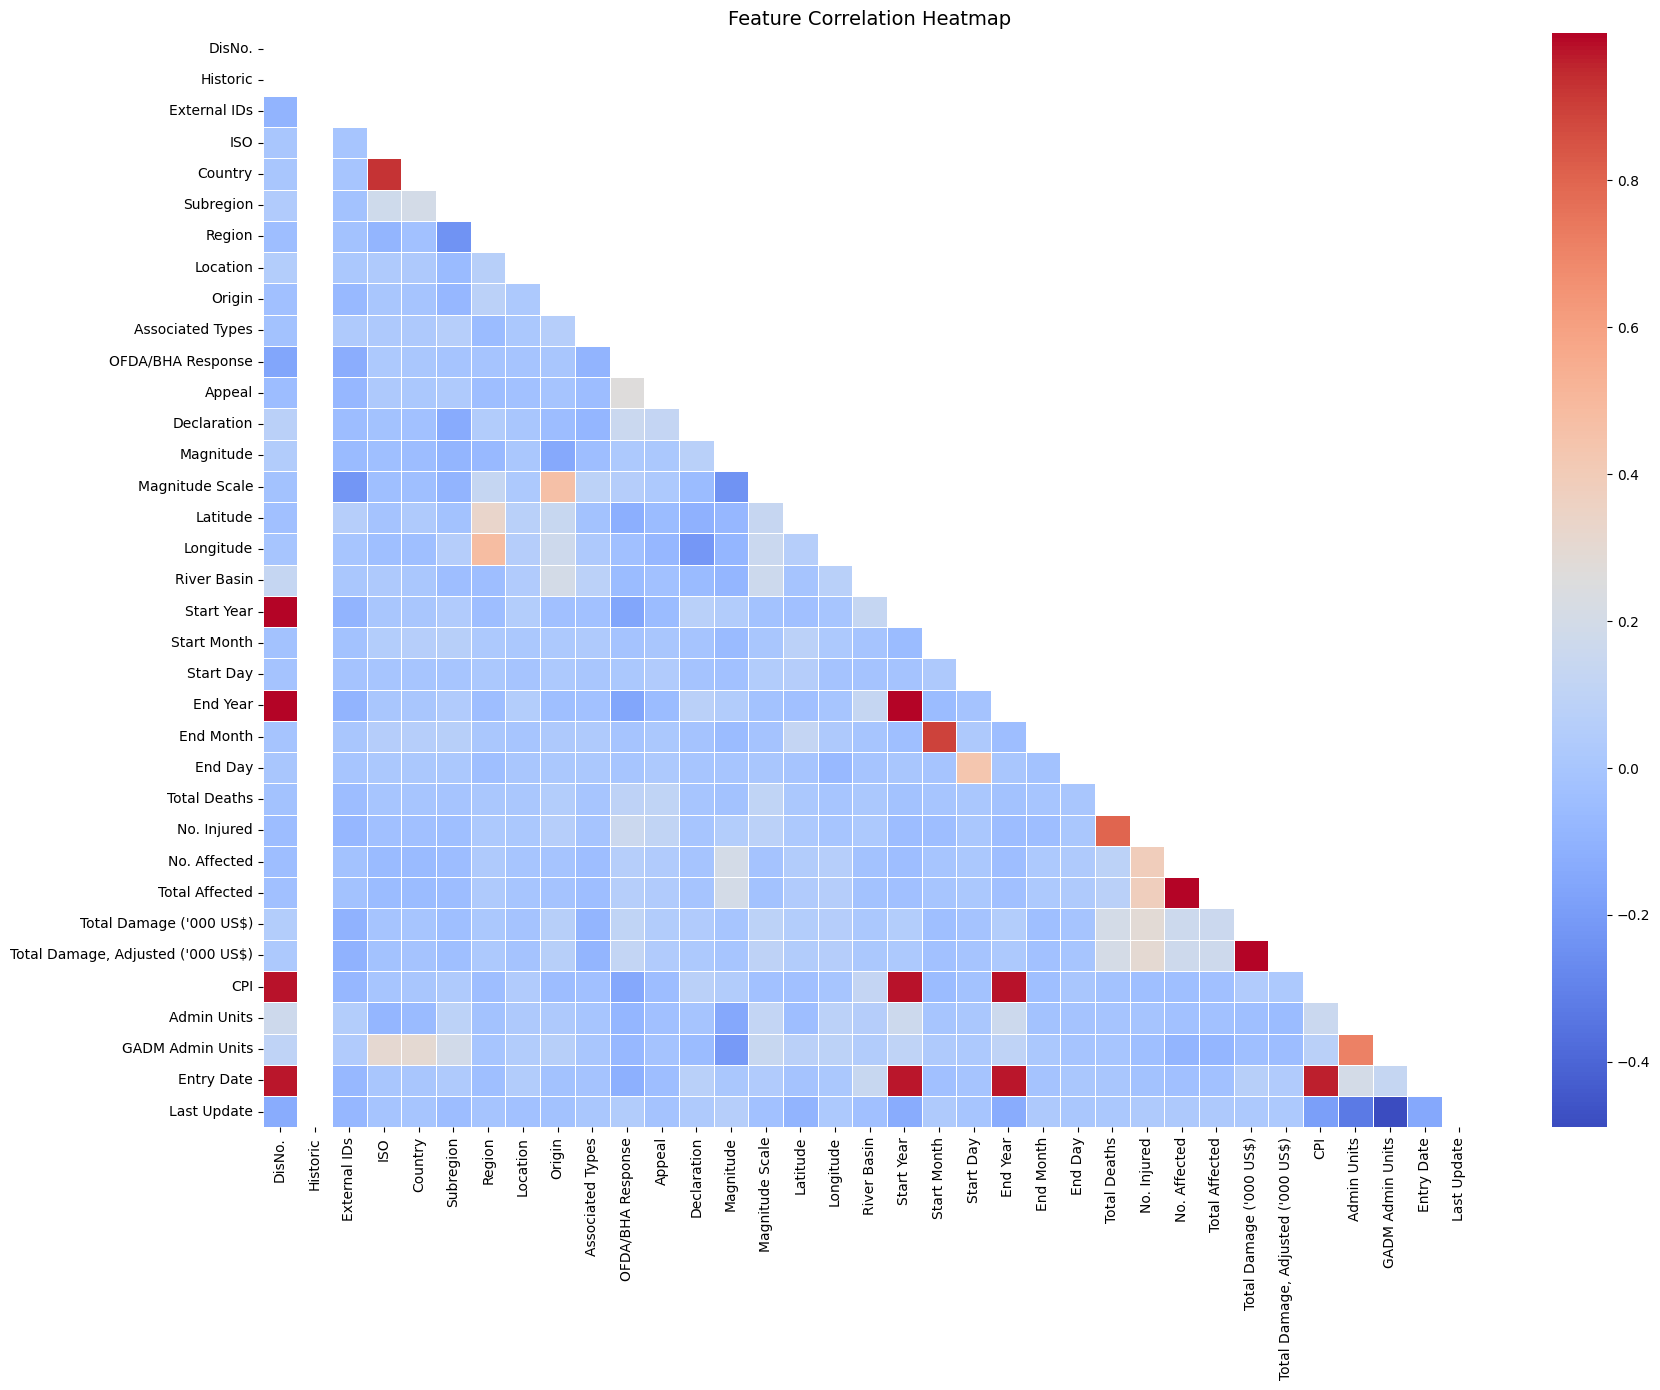

In [21]:
# Correlation matrix (numerical features only)
num_df = X_encoded.select_dtypes(include=np.number)
plt.figure(figsize=(18, 14))
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

In [22]:
# Train-test split (70:30 as per paper)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts())
print("\nTest class distribution (original imbalance preserved):")
print(y_test.value_counts())

Training set: (3691, 35)
Test set: (1583, 35)

Training class distribution:
Disaster Type
1    2969
0     486
2     236
Name: count, dtype: int64

Test class distribution (original imbalance preserved):
Disaster Type
1    1273
0     208
2     102
Name: count, dtype: int64


In [23]:
# Impute missing values using TRAINING median only
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)   # use training stats on test

# Scale features using TRAINING stats only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)   # use training stats on test

print("Imputation and scaling done.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Imputation and scaling done.
X_train_scaled shape: (3691, 35)
X_test_scaled shape: (1583, 35)


In [24]:
# Class distribution BEFORE SMOTE
before_smote = Counter(y_train)
print("Before SMOTE (training):")
for k, v in sorted(before_smote.items()):
    print(f"  Class {label_encoder_target.classes_[k]}: {v} samples")

# Apply SMOTE ONLY on training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)
    
after_smote = Counter(y_train_balanced)
print("\nAfter SMOTE (training):")
for k, v in sorted(after_smote.items()):
    print(f"  Class {label_encoder_target.classes_[k]}: {v} samples")

print("\nTest set remains UNCHANGED (realistic evaluation):")
print(Counter(y_test))

Before SMOTE (training):
  Class Earthquake: 486 samples
  Class Flood: 2969 samples
  Class Wildfire: 236 samples

After SMOTE (training):
  Class Earthquake: 2969 samples
  Class Flood: 2969 samples
  Class Wildfire: 2969 samples

Test set remains UNCHANGED (realistic evaluation):
Counter({1: 1273, 0: 208, 2: 102})


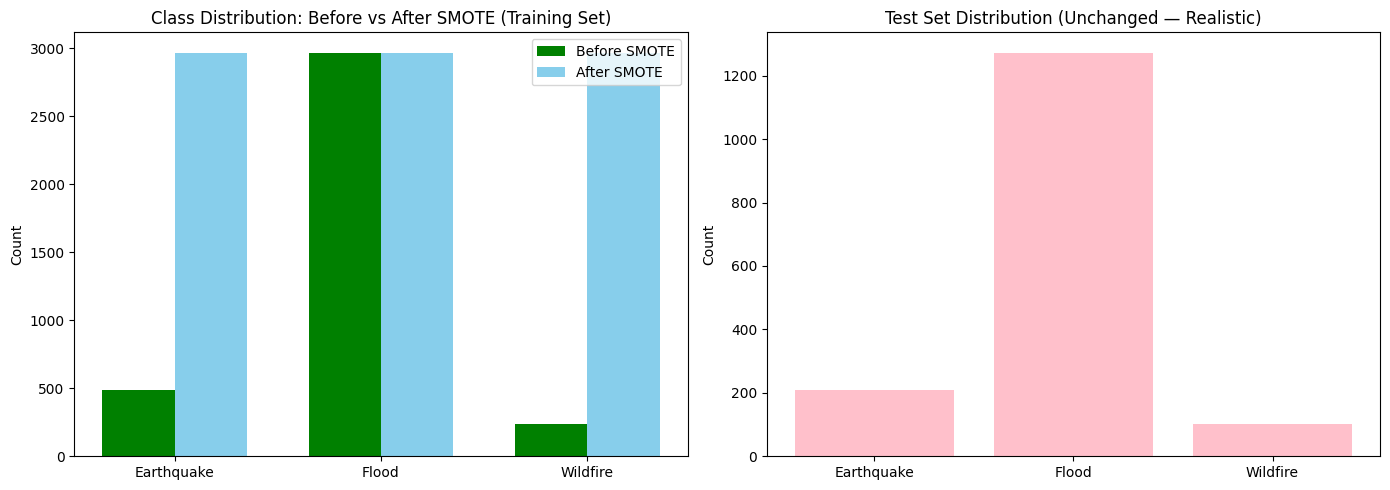

In [25]:
# Visualize before/after SMOTE
labels_idx = sorted(before_smote.keys())
class_names = label_encoder_target.classes_

before_counts = [before_smote[k] for k in labels_idx]
after_counts = [after_smote[k] for k in labels_idx]

x = np.arange(len(labels_idx))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(x - width/2, before_counts, width, label='Before SMOTE', color='green')
axes[0].bar(x + width/2, after_counts, width, label='After SMOTE', color='skyblue')
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_names)
axes[0].set_title('Class Distribution: Before vs After SMOTE (Training Set)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].bar(class_names, [Counter(y_test)[k] for k in labels_idx], color='pink')
axes[1].set_title('Test Set Distribution (Unchanged — Realistic)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# Logistic Regression
# ============================================================
labels = np.unique(y_test)
class_names = [str(label) for label in labels]

log_model = LogisticRegression(max_iter=2000, random_state=42)
log_model.fit(X_train_balanced, y_train_balanced)
y_pred_log = log_model.predict(X_test_scaled)

log_acc = accuracy_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log, average='weighted')
log_macro_f1 = f1_score(y_test, y_pred_log, average='macro')

print("=== Logistic Regression ===")
print(f"Accuracy: {log_acc*100:.2f}%")
print(f"Weighted F1: {log_f1:.4f}")
print(f"Macro F1: {log_macro_f1:.4f}")
print(classification_report(y_test, y_pred_log, target_names=class_names))

=== Logistic Regression ===
Accuracy: 84.46%
Weighted F1: 0.8769
Macro F1: 0.7659
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       208
           1       0.98      0.82      0.89      1273
           2       0.27      0.81      0.40       102

    accuracy                           0.84      1583
   macro avg       0.75      0.88      0.77      1583
weighted avg       0.94      0.84      0.88      1583



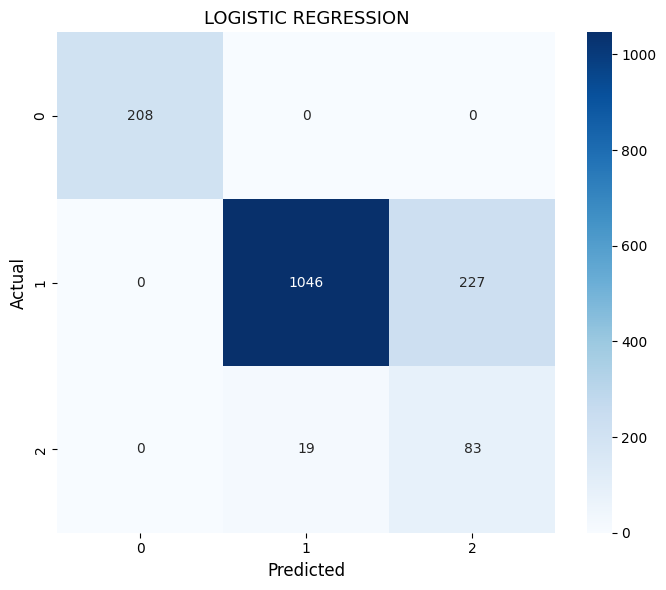

In [27]:
# Confusion Matrix for Logistic Regression
cm = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('LOGISTIC REGRESSION', fontsize=13)
plt.tight_layout()
plt.show()

In [28]:
# ============================================================
# Random Forest
# ============================================================
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=7,
    min_samples_split=5, min_samples_leaf=4,
    max_features='sqrt', random_state=42, n_jobs=-1
)
rf_model.fit(X_train_balanced, y_train_balanced)
y_pred_rf = rf_model.predict(X_test_scaled)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')
rf_macro_f1 = f1_score(y_test, y_pred_rf, average='macro')

print("=== Random Forest ===")
print(f"Accuracy: {rf_acc*100:.2f}%")
print(f"Weighted F1: {rf_f1:.4f}")
print(f"Macro F1: {rf_macro_f1:.4f}")
print(classification_report(y_test, y_pred_rf, target_names=class_names))

=== Random Forest ===
Accuracy: 93.37%
Weighted F1: 0.9420
Macro F1: 0.8630
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       208
           1       0.99      0.93      0.96      1273
           2       0.49      0.88      0.63       102

    accuracy                           0.93      1583
   macro avg       0.83      0.94      0.86      1583
weighted avg       0.96      0.93      0.94      1583



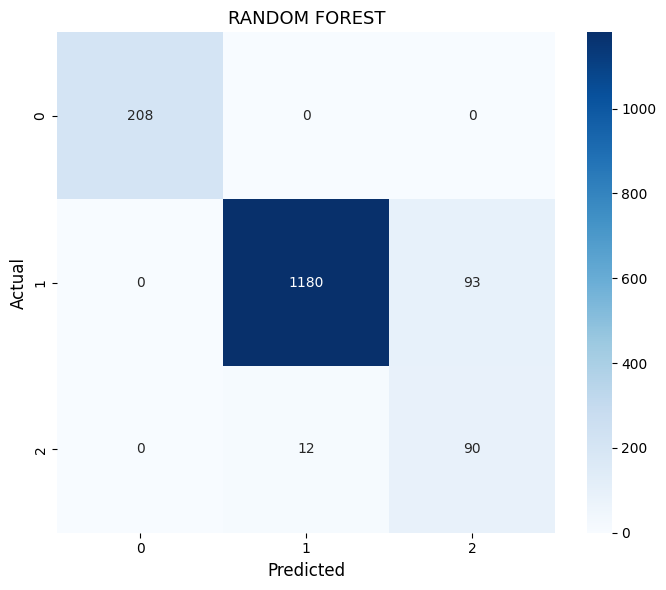

In [29]:
# Confusion Matrix for Random Forest
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('RANDOM FOREST', fontsize=13)
plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# SVM
# ============================================================
svm_model = SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train_balanced, y_train_balanced)
y_pred_svm = svm_model.predict(X_test_scaled)

svm_acc = accuracy_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm, average='weighted')
svm_macro_f1 = f1_score(y_test, y_pred_svm, average='macro')

print("=== SVM ===")
print(f"Accuracy: {svm_acc*100:.2f}%")
print(f"Weighted F1: {svm_f1:.4f}")
print(f"Macro F1: {svm_macro_f1:.4f}")
print(classification_report(y_test, y_pred_svm, target_names=class_names))

=== SVM ===
Accuracy: 90.65%
Weighted F1: 0.9169
Macro F1: 0.8012
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       208
           1       0.97      0.91      0.94      1273
           2       0.38      0.64      0.47       102

    accuracy                           0.91      1583
   macro avg       0.78      0.85      0.80      1583
weighted avg       0.93      0.91      0.92      1583



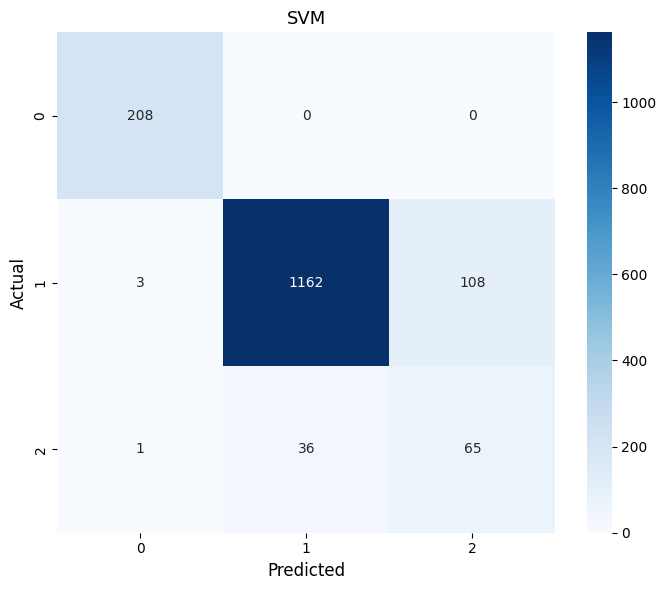

In [31]:
# Confusion Matrix for SVM
cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('SVM', fontsize=13)
plt.tight_layout()
plt.show()

Best K: 1


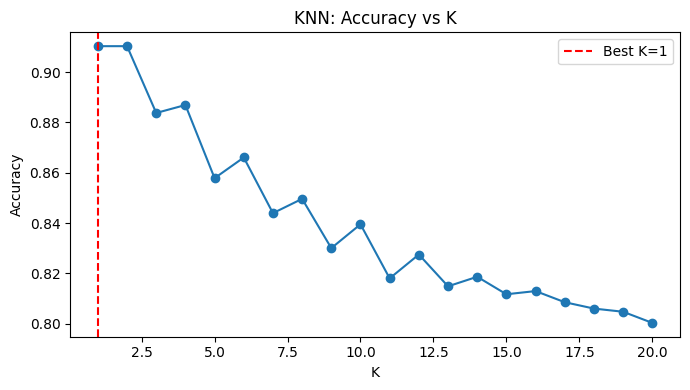

In [32]:
# ============================================================
# KNN — find best K
# ============================================================
k_values = range(1, 21)
knn_accs = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(X_train_balanced, y_train_balanced)
    knn_accs.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

best_k = k_values[np.argmax(knn_accs)]
print(f"Best K: {best_k}")

plt.figure(figsize=(7, 4))
plt.plot(list(k_values), knn_accs, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('KNN: Accuracy vs K')
plt.legend()
plt.tight_layout()
plt.show()


In [33]:

knn_model = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
knn_model.fit(X_train_balanced, y_train_balanced)
y_pred_knn = knn_model.predict(X_test_scaled)

knn_acc = accuracy_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn, average='weighted')
knn_macro_f1 = f1_score(y_test, y_pred_knn, average='macro')

print("=== KNN ===")
print(f"Accuracy: {knn_acc*100:.2f}%")
print(f"Weighted F1: {knn_f1:.4f}")
print(f"Macro F1: {knn_macro_f1:.4f}")
print(classification_report(y_test, y_pred_knn, target_names=class_names))

=== KNN ===
Accuracy: 91.03%
Weighted F1: 0.9181
Macro F1: 0.7969
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       208
           1       0.96      0.92      0.94      1273
           2       0.38      0.57      0.45       102

    accuracy                           0.91      1583
   macro avg       0.78      0.83      0.80      1583
weighted avg       0.93      0.91      0.92      1583



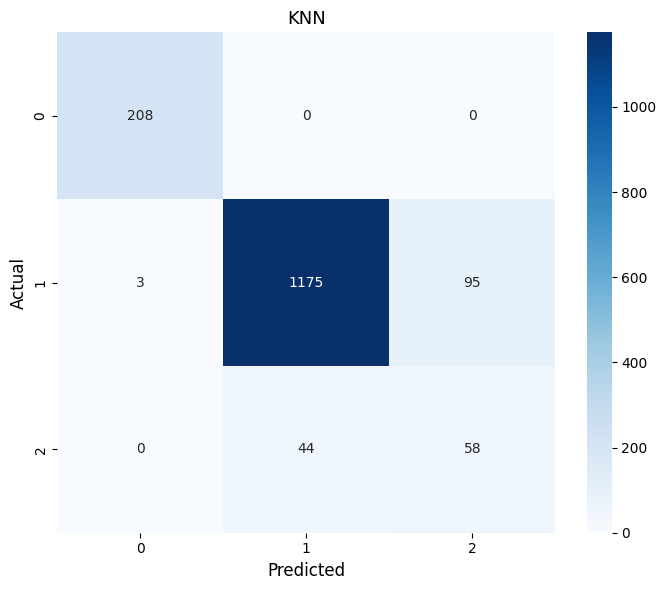

In [34]:
# Confusion Matrix for KNN
cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('KNN', fontsize=13)
plt.tight_layout()
plt.show()

In [35]:
#Input Dimension
input_dim = X_train_balanced.shape[1]
print(f"Input dimension: {input_dim}")


Input dimension: 35


In [36]:
#Class Weights 
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_balanced)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train_balanced)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)


In [37]:
#Improved Neural Network

class DisasterNet(nn.Module):
    def __init__(self, input_dim, embedding_dim=32, num_classes=3):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)

        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)

        self.fc3 = nn.Linear(64, 32)
        self.bn3 = nn.BatchNorm1d(32)

        self.fc4 = nn.Linear(32, embedding_dim)  # Bigger embedding

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

        # IMPORTANT: no ReLU before classifier
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x, return_embeddings=False):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)

        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)

        x = self.relu(self.bn3(self.fc3(x)))
        x = self.dropout(x)

        embeddings = self.fc4(x)
        logits = self.classifier(embeddings)   # FIXED

        if return_embeddings:
            return logits, embeddings
        return logits


In [38]:
#Model Initialization

nn_model = DisasterNet(input_dim=input_dim, embedding_dim=32, num_classes=3)
print(nn_model)

DisasterNet(
  (fc1): Linear(in_features=35, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=32, out_features=32, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=32, out_features=3, bias=True)
)


In [39]:
#Prepare Tensors 

X_train_tensor = torch.tensor(X_train_balanced, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_balanced.values if hasattr(y_train_balanced, 'values') else y_train_balanced, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [40]:
#Training Setup

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)   # FIXED
optimizer = optim.Adam(nn_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

In [41]:
#Training LOOP

num_epochs = 100   # increased
loss_history = []

nn_model.train()

for epoch in range(num_epochs):
    epoch_loss = 0.0

    for inputs, labels in train_loader:
        optimizer.zero_grad()

        outputs = nn_model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

Epoch [10/100] Loss: 0.1663
Epoch [20/100] Loss: 0.1324
Epoch [30/100] Loss: 0.1095
Epoch [40/100] Loss: 0.0937
Epoch [50/100] Loss: 0.1011
Epoch [60/100] Loss: 0.0842
Epoch [70/100] Loss: 0.0823
Epoch [80/100] Loss: 0.0854
Epoch [90/100] Loss: 0.0772
Epoch [100/100] Loss: 0.0823


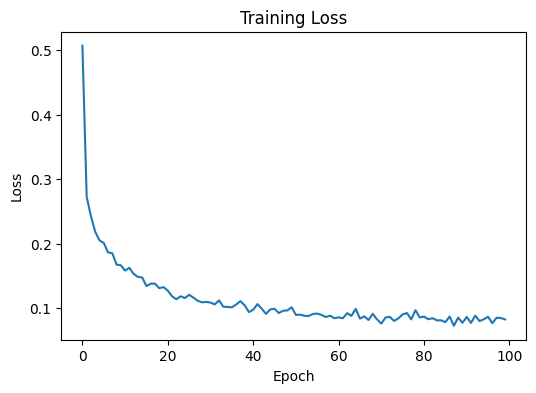

In [42]:
#Loss Graph

plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [43]:
# Extract embeddings
nn_model.eval()

with torch.no_grad():
    _, train_embeddings = nn_model(X_train_tensor, return_embeddings=True)
    _, test_embeddings = nn_model(X_test_tensor, return_embeddings=True)

train_embeddings = train_embeddings.numpy()
test_embeddings = test_embeddings.numpy()

print("Train embeddings:", train_embeddings.shape)
print("Test embeddings:", test_embeddings.shape)

Train embeddings: (8907, 32)
Test embeddings: (1583, 32)


In [44]:
# N-XGB Model
sample_weights = np.array([class_weights[y] for y in y_train_balanced])

nxgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

nxgb_model.fit(
    train_embeddings,
    y_train_balanced,
    sample_weight=sample_weights,
    eval_set=[(test_embeddings, y_test.values)],
    verbose=False
)

y_pred_nxgb = nxgb_model.predict(test_embeddings)
y_prob_nxgb = nxgb_model.predict_proba(test_embeddings)
nxgb_acc = accuracy_score(y_test, y_pred_nxgb)
nxgb_f1_weighted = f1_score(y_test, y_pred_nxgb, average='weighted')
nxgb_f1_macro = f1_score(y_test, y_pred_nxgb, average='macro')

print("=" * 50)
print("=== PROPOSED MODEL: Neural-XGBoost (N-XGB) ===")
print("=" * 50)
print(f"Accuracy:     {nxgb_acc * 100:.2f}%")
print(f"Weighted F1:  {nxgb_f1_weighted:.4f}")
print(f"Macro F1:     {nxgb_f1_macro:.4f}")
print()
print(classification_report(y_test, y_pred_nxgb, target_names=class_names))

=== PROPOSED MODEL: Neural-XGBoost (N-XGB) ===
Accuracy:     94.69%
Weighted F1:  0.9448
Macro F1:     0.8401

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       208
           1       0.96      0.97      0.97      1273
           2       0.60      0.51      0.55       102

    accuracy                           0.95      1583
   macro avg       0.86      0.83      0.84      1583
weighted avg       0.94      0.95      0.94      1583



In [45]:
print(Counter(y_train_balanced))

Counter({1: 2969, 0: 2969, 2: 2969})


In [46]:
print(np.unique(y_pred_nxgb))

[0 1 2]


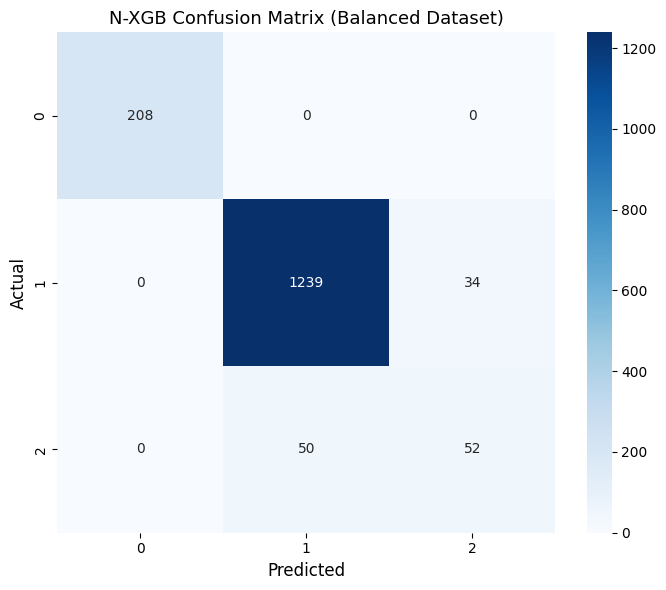

In [47]:
# Confusion Matrix for N-XGB
cm = confusion_matrix(y_test, y_pred_nxgb)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('N-XGB Confusion Matrix (Balanced Dataset)', fontsize=13)
plt.tight_layout()
plt.show()

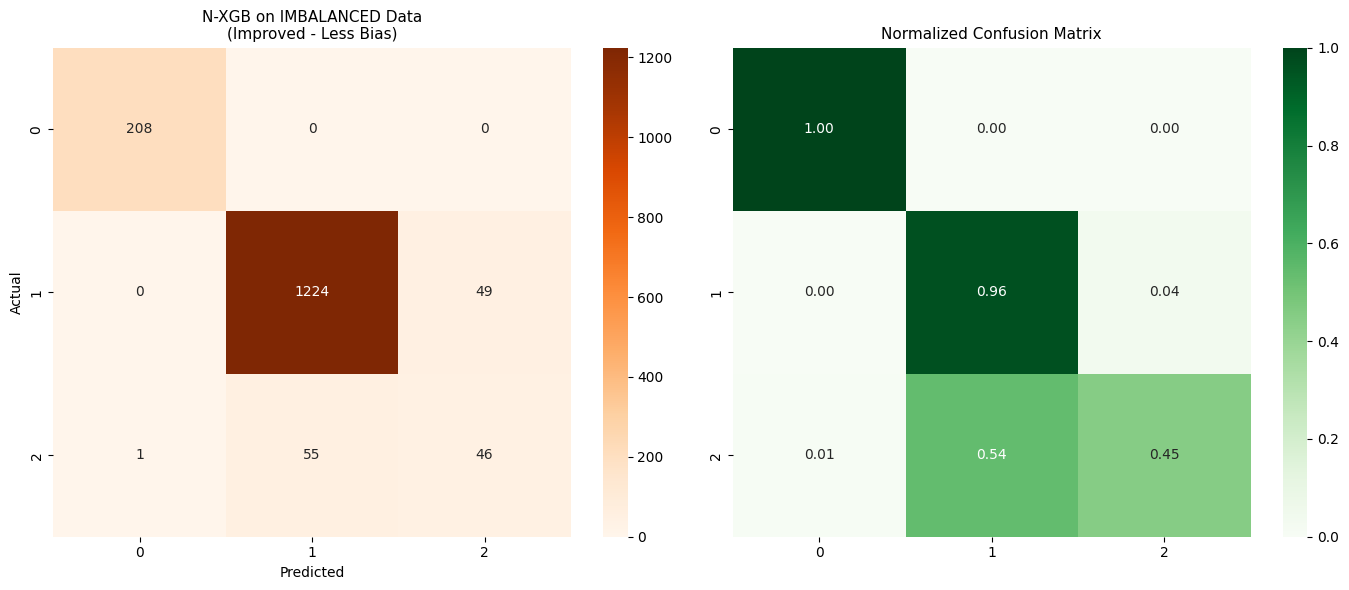

<Figure size 640x480 with 0 Axes>

Imbalanced Accuracy: 93.37% — looks OK but minority classes fail
Imbalanced Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       208
           1       0.96      0.96      0.96      1273
           2       0.48      0.45      0.47       102

    accuracy                           0.93      1583
   macro avg       0.81      0.80      0.81      1583
weighted avg       0.93      0.93      0.93      1583



In [48]:
# Train N-XGB on imbalanced (no SMOTE) to demonstrate the problem

#Class Weights
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

#Neural Model
nn_model_imb = DisasterNet(input_dim=input_dim, embedding_dim=32)

train_tensor_imb = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor_imb = torch.tensor(y_train.values, dtype=torch.long)

dataset_imb = TensorDataset(train_tensor_imb, y_train_tensor_imb)
loader_imb = DataLoader(dataset_imb, batch_size=64, shuffle=True)

#Weighted Loss
criterion_imb = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer_imb = optim.Adam(nn_model_imb.parameters(), lr=0.001, weight_decay=1e-4)

#Training
nn_model_imb.train()

for epoch in range(60):   # increased
    for inputs, labels in loader_imb:
        optimizer_imb.zero_grad()

        out = nn_model_imb(inputs)
        loss = criterion_imb(out, labels)

        loss.backward()
        optimizer_imb.step()

#Extract Embedding
nn_model_imb.eval()

with torch.no_grad():
    _, train_emb_imb = nn_model_imb(train_tensor_imb, return_embeddings=True)
    _, test_emb_imb = nn_model_imb(X_test_tensor, return_embeddings=True)

train_emb_imb = train_emb_imb.numpy()
test_emb_imb = test_emb_imb.numpy()

#XGBoost with sample weights
sample_weights_imb = np.array([class_weights[y] for y in y_train])

xgb_imb = XGBClassifier(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

xgb_imb.fit(
    train_emb_imb,
    y_train.values,
    sample_weight=sample_weights_imb,
    verbose=False
)

y_pred_imb = xgb_imb.predict(test_emb_imb)

cm_imb = confusion_matrix(y_test, y_pred_imb)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_imb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])

axes[0].set_title('N-XGB on IMBALANCED Data\n(Improved - Less Bias)', fontsize=11)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_norm = cm_imb.astype('float') / cm_imb.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])

axes[1].set_title('Normalized Confusion Matrix', fontsize=11)

plt.tight_layout()
plt.show()

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('N-XGB on BALANCED Data\n(With SMOTE — fair across all classes)', fontsize=11)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('Effect of SMOTE on Confusion Matrix', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

imb_acc = accuracy_score(y_test, y_pred_imb)
print(f"Imbalanced Accuracy: {imb_acc*100:.2f}% — looks OK but minority classes fail")
print("Imbalanced Classification Report:")
print(classification_report(y_test, y_pred_imb, target_names=class_names))

                     Accuracy  Weighted F1  Macro F1
Logistic Regression     84.46        87.69     76.59
Random Forest           93.37        94.20     86.30
SVM                     90.65        91.69     80.12
KNN                     91.03        91.81     79.69
N-XGB (Proposed)        94.69        94.48     84.01


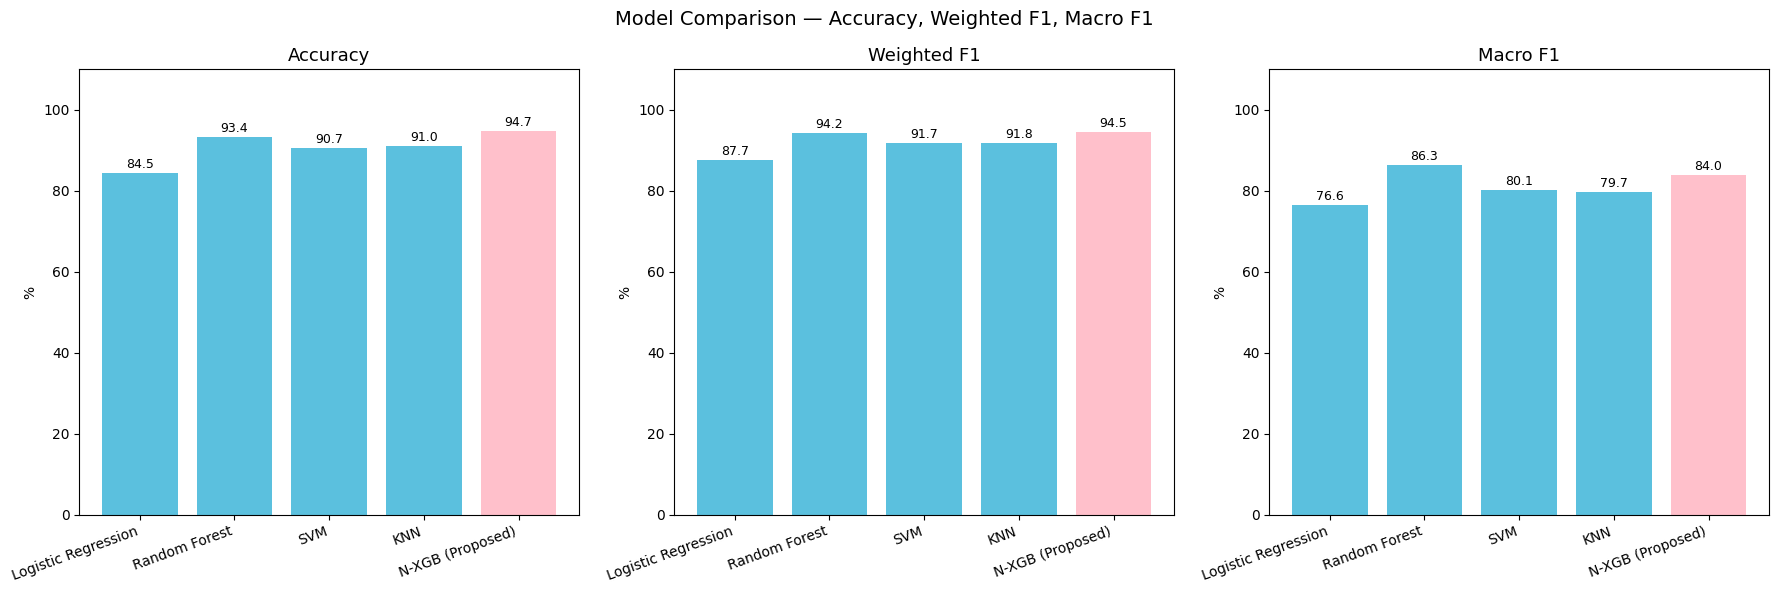

In [49]:
results = {
    'Logistic Regression': {'Accuracy': log_acc, 'Weighted F1': log_f1, 'Macro F1': log_macro_f1},
    'Random Forest':        {'Accuracy': rf_acc,  'Weighted F1': rf_f1,  'Macro F1': rf_macro_f1},
    'SVM':                  {'Accuracy': svm_acc, 'Weighted F1': svm_f1, 'Macro F1': svm_macro_f1},
    'KNN':                  {'Accuracy': knn_acc, 'Weighted F1': knn_f1, 'Macro F1': knn_macro_f1},
    'N-XGB (Proposed)':     {'Accuracy': nxgb_acc, 'Weighted F1': nxgb_f1_weighted, 'Macro F1': nxgb_f1_macro},
}

results_df = pd.DataFrame(results).T * 100
results_df = results_df.round(2)
print(results_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['Accuracy', 'Weighted F1', 'Macro F1']
colors_bar = ['pink' if 'N-XGB' in m else '#5bc0de' for m in results_df.index]

for ax, metric in zip(axes, metrics):
    bars = ax.bar(results_df.index, results_df[metric], color=colors_bar)
    ax.set_ylim(0, 110)
    ax.set_title(metric, fontsize=13)
    ax.set_ylabel('%')
    ax.set_xticklabels(results_df.index, rotation=20, ha='right')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Comparison — Accuracy, Weighted F1, Macro F1', fontsize=14)
plt.tight_layout()
plt.show()

In [50]:
# Final summary
print("="*65)
print("       NEURAL-XGBOOST (N-XGB) — FINAL RESULTS SUMMARY")
print("="*65)
print(f"\nDataset: EM-DAT Disaster Database")
print(f"Classes: Flood / Earthquake / Wildfire")
print(f"Train/Test Split: 70:30")
print(f"SMOTE: Applied on training data only")
print()
print("--- Model Performance ---")
print(f"{'Model':<25} {'Accuracy':>10} {'Wtd F1':>10} {'Macro F1':>10}")
print("-"*55)
for model_name, vals in results.items():
    print(f"{model_name:<25} {vals['Accuracy']*100:>9.2f}% {vals['Weighted F1']*100:>9.2f}% {vals['Macro F1']*100:>9.2f}%")
print("-"*55)
print()
print("--- N-XGB Per-Class Results ---")
report = classification_report(y_test, y_pred_nxgb, target_names=class_names, output_dict=True)
for cls in class_names:
    r = report[cls]
    print(f"  {cls:<12} Precision={r['precision']:.4f}  Recall={r['recall']:.4f}  F1={r['f1-score']:.4f}")
print()

       NEURAL-XGBOOST (N-XGB) — FINAL RESULTS SUMMARY

Dataset: EM-DAT Disaster Database
Classes: Flood / Earthquake / Wildfire
Train/Test Split: 70:30
SMOTE: Applied on training data only

--- Model Performance ---
Model                       Accuracy     Wtd F1   Macro F1
-------------------------------------------------------
Logistic Regression           84.46%     87.69%     76.59%
Random Forest                 93.37%     94.20%     86.30%
SVM                           90.65%     91.69%     80.12%
KNN                           91.03%     91.81%     79.69%
N-XGB (Proposed)              94.69%     94.48%     84.01%
-------------------------------------------------------

--- N-XGB Per-Class Results ---
  0            Precision=1.0000  Recall=1.0000  F1=1.0000
  1            Precision=0.9612  Recall=0.9733  F1=0.9672
  2            Precision=0.6047  Recall=0.5098  F1=0.5532



In [51]:
import shap

# Embedding feature names
embedding_feature_names = [f'neural_emb_{i}' for i in range(train_embeddings.shape[1])]

# TreeExplainer on XGBoost
explainer = shap.TreeExplainer(nxgb_model)

raw_shap = explainer.shap_values(test_embeddings)

if isinstance(raw_shap, np.ndarray) and raw_shap.ndim == 3:
    # shape: (n_samples, n_features, n_classes) — transpose to list
    shap_values = [raw_shap[:, :, c] for c in range(raw_shap.shape[2])]
    print('SHAP format: 3-D array -> converted to list of', len(shap_values), 'arrays')
else:
    # Already a list of (n_samples, n_features)
    shap_values = raw_shap
    print('SHAP format: list of', len(shap_values), 'arrays')

print('Per-class SHAP array shape:', shap_values[0].shape)
print('Classes:', class_names)


SHAP format: 3-D array -> converted to list of 3 arrays
Per-class SHAP array shape: (1583, 32)
Classes: ['0', '1', '2']


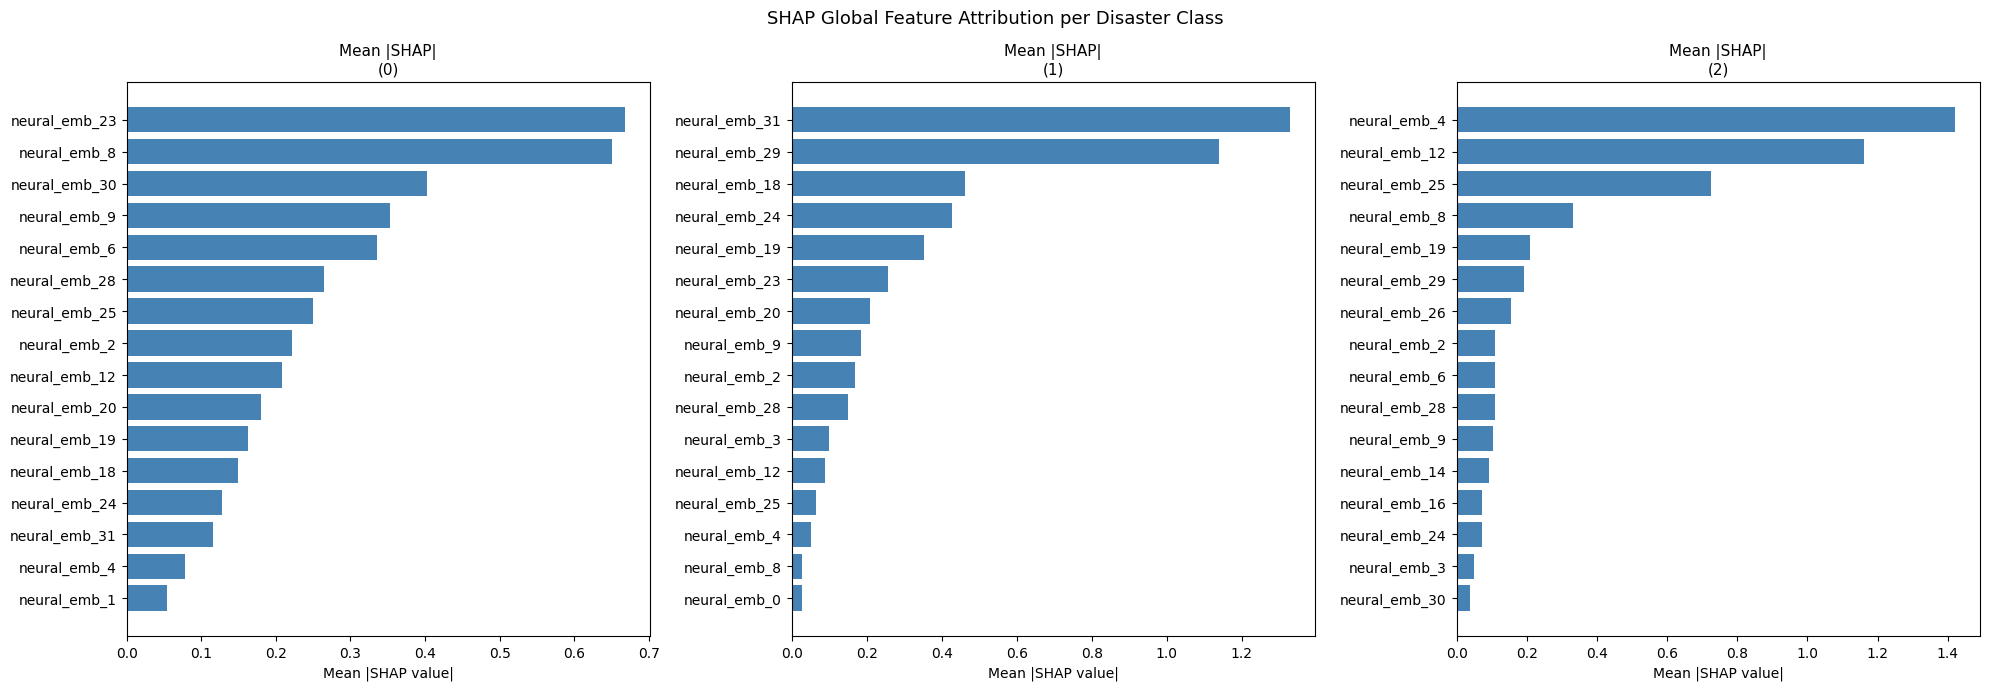

In [52]:
# SHAP Summary Bar Plot — Global Feature Importance (per class)
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for cls_idx, cls_name in enumerate(class_names):
    # shap_values[cls_idx] has shape (n_test, n_emb_features) — matches test_embeddings
    mean_abs_shap = np.abs(shap_values[cls_idx]).mean(axis=0)  # (n_features,)
    sorted_idx = np.argsort(mean_abs_shap)[::-1][:16]
    feat_labels = [embedding_feature_names[i] for i in sorted_idx]
    feat_vals   = mean_abs_shap[sorted_idx]

    axes[cls_idx].barh(feat_labels[::-1], feat_vals[::-1], color='steelblue')
    axes[cls_idx].set_title(f'Mean |SHAP|\n({cls_name})', fontsize=11)
    axes[cls_idx].set_xlabel('Mean |SHAP value|')

plt.suptitle('SHAP Global Feature Attribution per Disaster Class', fontsize=13)
plt.tight_layout()
plt.show()


Beeswarm for class: 1


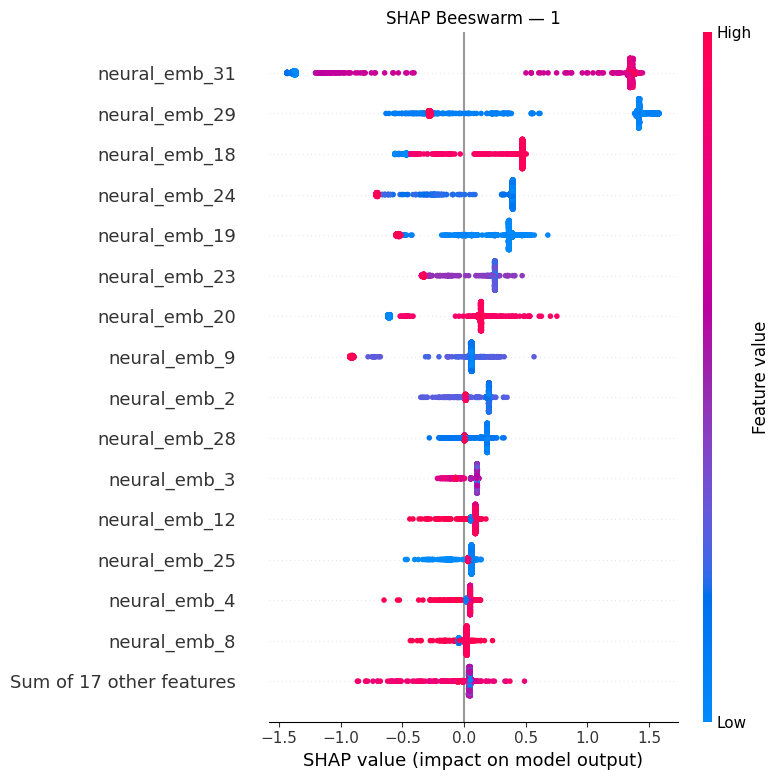

In [53]:
# SHAP Beeswarm for the most-predicted class
pred_class_idx = int(np.bincount(y_pred_nxgb).argmax())
print(f'Beeswarm for class: {class_names[pred_class_idx]}')

shap_exp = shap.Explanation(
    values=shap_values[pred_class_idx],          # (n_test, n_features)
    base_values=np.full(len(test_embeddings),
                        explainer.expected_value[pred_class_idx]
                        if hasattr(explainer.expected_value, '__len__')
                        else explainer.expected_value),
    data=test_embeddings,
    feature_names=embedding_feature_names
)

plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_exp, max_display=16, show=False)
plt.title(f'SHAP Beeswarm — {class_names[pred_class_idx]}')
plt.tight_layout()
plt.show()


Sample #0: Predicted=1, Actual=1


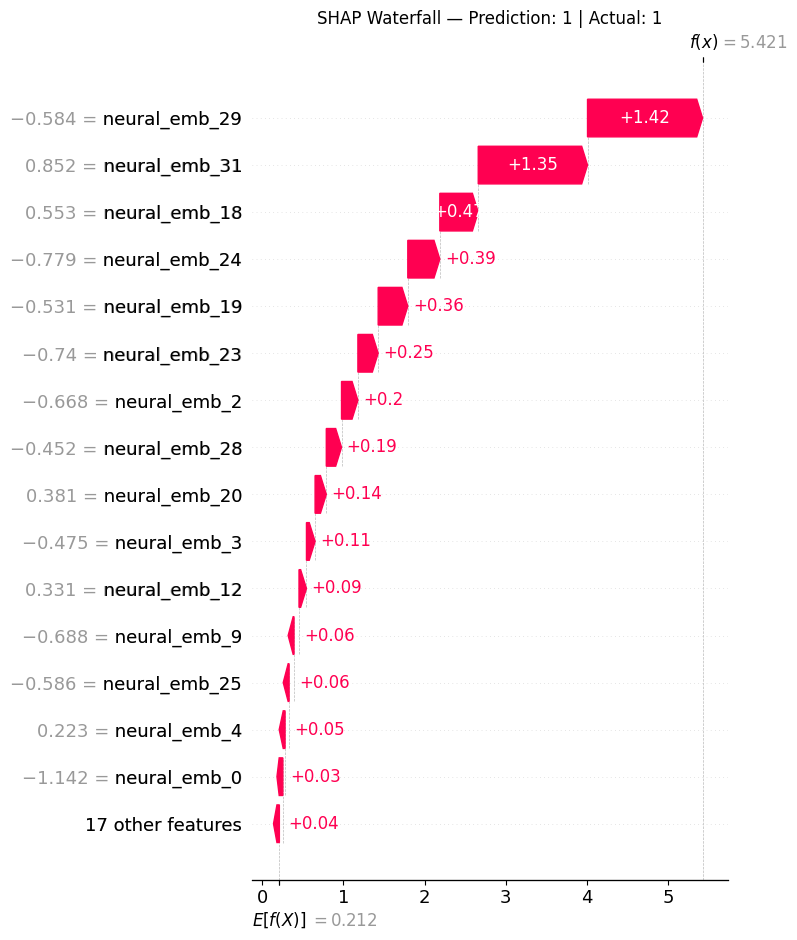

In [54]:
# SHAP Waterfall — single sample explanation
sample_idx = 0
pred_cls   = y_pred_nxgb[sample_idx]
pred_label = class_names[pred_cls]
true_label = class_names[y_test.values[sample_idx]]
print(f'Sample #{sample_idx}: Predicted={pred_label}, Actual={true_label}')

ev = (explainer.expected_value[pred_cls]
      if hasattr(explainer.expected_value, '__len__')
      else float(explainer.expected_value))

shap_single = shap.Explanation(
    values=shap_values[pred_cls][sample_idx],     # (n_features,)
    base_values=ev,
    data=test_embeddings[sample_idx],
    feature_names=embedding_feature_names
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_single, max_display=16, show=False)
plt.title(f'SHAP Waterfall — Prediction: {pred_label} | Actual: {true_label}')
plt.tight_layout()
plt.show()


In [55]:
from scipy.stats import entropy as scipy_entropy

def compute_drsi(probs, shap_vals_for_pred_class, w_prob=0.5, w_shap=0.3, w_conf=0.2):
    """
    Compute Disaster Risk Score Index (DRSI) — 0 to 100 scale.

    Parameters
    ----------
    probs : np.array (n, n_classes)
    shap_vals_for_pred_class : np.array (n, n_features)
    Returns
    -------
    drsi_scores : np.array (n,)
    risk_tiers  : list of str
    """
    n_classes = probs.shape[1]

    # 1. Max probability
    p_max = probs.max(axis=1)

    # 2. SHAP attribution strength (normalised |SHAP| sum)
    shap_abs = np.abs(shap_vals_for_pred_class).sum(axis=1)
    denom = shap_abs.max() if shap_abs.max() > 0 else 1.0
    shap_norm = shap_abs / denom

    # 3. Confidence = 1 - normalised Shannon entropy
    max_ent = np.log(n_classes)
    ent = np.array([scipy_entropy(p + 1e-12) for p in probs])
    confidence = 1.0 - np.clip(ent / max_ent, 0, 1)

    drsi = np.clip((w_prob * p_max + w_shap * shap_norm + w_conf * confidence) * 100, 0, 100)

    def tier(s):
        if s < 40:   return 'Low'
        elif s < 70: return 'Moderate'
        elif s < 85: return 'High'
        else:        return 'Critical'

    return drsi, [tier(s) for s in drsi]


# Extract SHAP for each sample's predicted class
shap_for_pred = np.array([
    shap_values[y_pred_nxgb[i]][i]   # shap_values is now a list of (n_test, n_feat)
    for i in range(len(y_pred_nxgb))
])

drsi_scores, risk_tiers = compute_drsi(y_prob_nxgb, shap_for_pred)

print(f'DRSI computed for {len(drsi_scores)} samples.')
print(f'Mean DRSI : {drsi_scores.mean():.1f}')
print(f'Min  DRSI : {drsi_scores.min():.1f}')
print(f'Max  DRSI : {drsi_scores.max():.1f}')
print(f'\nRisk Tier Distribution:')
print(pd.Series(risk_tiers).value_counts())


DRSI computed for 1583 samples.
Mean DRSI : 95.8
Min  DRSI : 53.6
Max  DRSI : 99.9

Risk Tier Distribution:
Critical    1541
High          27
Moderate      15
Name: count, dtype: int64


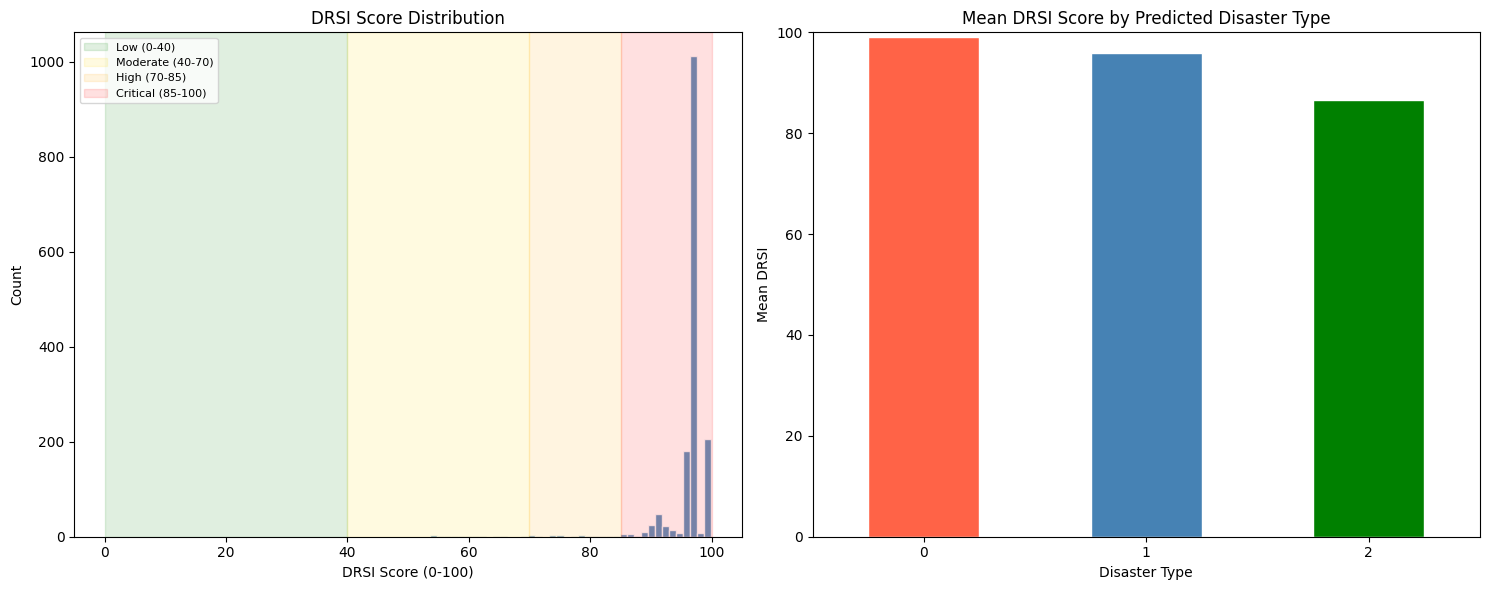


Sample predictions with DRSI scores:
  Actual Predicted       DRSI Risk Tier  Correct
0      1         1  96.809021  Critical     True
1      2         2  89.741064  Critical     True
2      0         0  99.187432  Critical     True
3      1         1  96.834314  Critical     True
4      2         2  92.752650  Critical     True
5      1         1  96.808326  Critical     True
6      0         0  99.187424  Critical     True
7      1         1  96.808346  Critical     True
8      1         1  96.868282  Critical     True
9      2         2  78.504245      High     True


In [56]:
# Visualize DRSI Distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram
tier_colors = {'Low': 'green', 'Moderate': 'gold', 'High': 'orange', 'Critical': 'red'}
tier_ranges = {'Low': (0, 40), 'Moderate': (40, 70), 'High': (70, 85), 'Critical': (85, 100)}

axes[0].hist(drsi_scores, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
for tier_name, (lo, hi) in tier_ranges.items():
    axes[0].axvspan(lo, hi, alpha=0.12, color=tier_colors[tier_name], label=f'{tier_name} ({lo}-{hi})')
axes[0].set_title('DRSI Score Distribution', fontsize=12)
axes[0].set_xlabel('DRSI Score (0-100)')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

# Bar chart by predicted class
drsi_df = pd.DataFrame({
    'DRSI': drsi_scores,
    'Predicted': [class_names[p] for p in y_pred_nxgb],
    'Risk Tier': risk_tiers
})
drsi_df.groupby('Predicted')['DRSI'].mean().plot(kind='bar', color=['tomato','steelblue','green'],
                                                   ax=axes[1], edgecolor='white')
axes[1].set_title('Mean DRSI Score by Predicted Disaster Type', fontsize=12)
axes[1].set_ylabel('Mean DRSI')
axes[1].set_xlabel('Disaster Type')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

# Show sample DRSI results
print("\nSample predictions with DRSI scores:")
sample_df = drsi_df.head(10).copy()
sample_df['Actual'] = [class_names[y] for y in y_test.values[:10]]
sample_df['Correct'] = sample_df['Predicted'] == sample_df['Actual']
print(sample_df[['Actual','Predicted','DRSI','Risk Tier','Correct']].to_string())

In [57]:
COUNTRY_LIST = [
    'Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Angola',
    'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan',
    'Bahamas', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium',
    'Belize', 'Benin', 'Bhutan', 'Bolivia (Plurinational State of)',
    'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Bulgaria',
    'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon',
    'Canada', 'Canary Islands', 'Central African Republic', 'Chad',
    'Chile', 'China', 'China, Hong Kong Special Administrative Region',
    'Colombia', 'Comoros', 'Congo', 'Costa Rica', 'Croatia', 'Cuba',
    'Cyprus', 'Czechia', "Côte d'Ivoire",
    "Democratic People's Republic of Korea",
    'Democratic Republic of the Congo', 'Djibouti', 'Dominica',
    'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador',
    'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Ethiopia', 'Fiji',
    'Finland', 'France', 'French Guiana', 'French Polynesia', 'Gabon',
    'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Guadeloupe',
    'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Haiti',
    'Honduras', 'Hungary', 'Iceland', 'India', 'Indonesia',
    'Iran (Islamic Republic of)', 'Iraq', 'Ireland', 'Israel', 'Italy',
    'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kiribati',
    'Kuwait', 'Kyrgyzstan', "Lao People's Democratic Republic",
    'Latvia', 'Lebanon', 'Lesotho', 'Liberia', 'Libya', 'Lithuania',
    'Luxembourg', 'Madagascar', 'Malawi', 'Malaysia', 'Maldives',
    'Mali', 'Marshall Islands', 'Martinique', 'Mauritania', 'Mauritius',
    'Mexico', 'Micronesia (Federated States of)', 'Mongolia',
    'Montenegro', 'Morocco', 'Mozambique', 'Myanmar', 'Namibia',
    'Nepal', 'Netherlands (Kingdom of the)', 'New Zealand', 'Nicaragua',
    'Niger', 'Nigeria', 'North Macedonia', 'Norway', 'Oman', 'Pakistan',
    'Panama', 'Papua New Guinea', 'Paraguay', 'Peru', 'Philippines',
    'Poland', 'Portugal', 'Puerto Rico', 'Qatar', 'Republic of Korea',
    'Republic of Moldova', 'Romania', 'Russian Federation', 'Rwanda',
    'Saint Lucia', 'Saint Vincent and the Grenadines', 'Samoa',
    'Sao Tome and Principe', 'Saudi Arabia', 'Senegal', 'Serbia',
    'Serbia Montenegro', 'Seychelles', 'Sierra Leone', 'Slovakia',
    'Slovenia', 'Solomon Islands', 'Somalia', 'South Africa',
    'South Sudan', 'Spain', 'Sri Lanka', 'State of Palestine', 'Sudan',
    'Suriname', 'Sweden', 'Switzerland', 'Syrian Arab Republic',
    'Taiwan (Province of China)', 'Tajikistan', 'Thailand',
    'Timor-Leste', 'Togo', 'Tonga', 'Trinidad and Tobago', 'Tunisia',
    'Turkmenistan', 'Türkiye', 'Uganda', 'Ukraine',
    'United Arab Emirates',
    'United Kingdom of Great Britain and Northern Ireland',
    'United Republic of Tanzania', 'United States of America',
    'Uruguay', 'Uzbekistan', 'Vanuatu',
    'Venezuela (Bolivarian Republic of)', 'Viet Nam', 'Yemen',
    'Zambia', 'Zimbabwe'
]
REGION_LIST = ['Africa', 'Americas', 'Asia', 'Europe', 'Oceania']

import pickle

with open("feature_columns.pkl", "rb") as f:
    feature_columns = pickle.load(f)


def build_full_input(feature_columns,
                     magnitude, total_deaths, no_affected, total_damage,
                     start_year, start_month, end_year, end_month,
                     country_enc, region_enc):

    x = np.zeros(len(feature_columns), dtype=np.float64)

    mapping = {
        'Magnitude': magnitude,
        'Total Deaths': total_deaths,
        'No. Affected': no_affected,
        "Total Damage ('000 US$)": total_damage,
        'Start Year': start_year,
        'Start Month': start_month,
        'End Year': end_year,
        'End Month': end_month,
        'Country': country_enc,
        'Region': region_enc
    }

    for i, col in enumerate(feature_columns):
        if col in mapping:
            x[i] = mapping[col]
        else:
            x[i] = 0   # keep as 0 (safe default)

    return x.reshape(1, -1)

# ============================================================
# PREDICTION FUNCTION (FIXED)
# ============================================================
def predict_disaster(magnitude, total_deaths, no_affected, total_damage,
                     start_year, start_month, end_year, end_month,
                     country_name, region_name):

    try:
        # -------------------------------
        # 1. Encode Country & Region
        # -------------------------------
        le_country = feature_encoders['Country']
        le_region  = feature_encoders['Region']

        country_enc = int(le_country.transform([country_name])[0]) \
            if country_name in le_country.classes_ else 0

        region_enc = int(le_region.transform([region_name])[0]) \
            if region_name in le_region.classes_ else 0

        # -------------------------------
        # 2. Input Array
        # -------------------------------
        input_array = build_full_input(
            feature_columns,
            magnitude, total_deaths, no_affected, total_damage,
            start_year, start_month, end_year, end_month,
            country_enc, region_enc
        )

        # -------------------------------
        # 3. Preprocessing
        # -------------------------------
        input_imp    = imputer.transform(input_array)
        input_scaled = scaler.transform(input_imp)

        # -------------------------------
        # 4. Neural Embeddings
        # -------------------------------
        input_tensor = torch.tensor(input_scaled, dtype=torch.float32)

        nn_model.eval()
        with torch.no_grad():
            _, embedding = nn_model(input_tensor, return_embeddings=True)
            embedding_np = embedding.numpy()

        # -------------------------------
        # 5. XGBoost Prediction
        # -------------------------------
        pred_class = int(nxgb_model.predict(embedding_np)[0])
        pred_probs = nxgb_model.predict_proba(embedding_np)[0]
        pred_label = label_encoder_target.classes_[pred_class]

        # -------------------------------
        # 6. SHAP (FIXED)
        # -------------------------------
        explainer = shap.TreeExplainer(nxgb_model)
        shap_values = explainer.shap_values(embedding_np)

        if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
            shap_values = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

        shap_for_pred = shap_values[pred_class][0]

        # -------------------------------
        # 7. DRSI (FIXED BUG HERE)
        # -------------------------------
        shap_abs = float(np.abs(shap_for_pred).sum())
        global_max = float(np.abs(shap_for_pred).max()) + 1e-8

        shap_norm = np.clip(shap_abs / global_max, 0, 1)

        from scipy.stats import entropy
        max_ent = np.log(len(class_names))
        ent = entropy(pred_probs + 1e-12)
        confidence = 1.0 - np.clip(ent / max_ent, 0, 1)

        drsi_score = np.clip(
            (0.5 * float(pred_probs.max()) +
             0.3 * shap_norm +
             0.2 * confidence) * 100,
            0, 100
        )

        # -------------------------------
        # 8. Risk Tier
        # -------------------------------
        def tier(s):
            if s < 40: return "🟢 Low"
            elif s < 70: return "🟡 Moderate"
            elif s < 85: return "🟠 High"
            else: return "🔴 Critical"

        risk_tier = tier(drsi_score)

        # -------------------------------
        # 9. Result Text
        # -------------------------------
        result = f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PREDICTED DISASTER: {pred_label.upper()}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Class Probabilities:
"""

        for i, cls in enumerate(class_names):
            mark = "◄" if i == pred_class else ""
            result += f"{cls:<12}: {pred_probs[i]*100:.1f}% {mark}\n"

        result += f"""
DRSI Score : {drsi_score:.1f} / 100
Risk Tier  : {risk_tier}

Input:
Country: {country_name}
Region : {region_name}
"""

        # -------------------------------
        # 10. Plot (SINGLE FIG ONLY)
        # -------------------------------
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # SHAP bar
        names = [f'emb_{i}' for i in range(len(shap_for_pred))]
        idx = np.argsort(np.abs(shap_for_pred))[::-1][:10]

        axes[0].barh(
            [names[i] for i in idx][::-1],
            shap_for_pred[idx][::-1]
        )
        axes[0].set_title("SHAP Explanation")

        # DRSI bar
        axes[1].barh(["DRSI"], [100], color="lightgray")
        axes[1].barh(["DRSI"], [drsi_score], color="red")
        axes[1].set_xlim(0, 100)
        axes[1].set_title(f"Risk: {risk_tier}")

        plt.tight_layout()

        return result, fig

    except Exception as e:
        return f"Error: {str(e)}", None

In [64]:
# ============================================================
# GRADIO INTERFACE
# ============================================================
print("Running on local URL:  http://127.0.0.1:7866")
with gr.Blocks(title="N-XGB Disaster Prediction") as demo:

    gr.Markdown("# 🌋 Neural-XGBoost Disaster Prediction System")

    with gr.Row():

        with gr.Column():
            magnitude    = gr.Number(label="Magnitude", value=5)
            total_deaths = gr.Number(label="Total Deaths", value=50)
            no_affected  = gr.Number(label="No Affected", value=10000)
            total_damage = gr.Number(label="Damage ('000 US$)", value=5000)

        with gr.Column():
            start_year  = gr.Number(label="Start Year", value=2020)
            start_month = gr.Slider(1,12,value=6)
            end_year    = gr.Number(label="End Year", value=2020)
            end_month   = gr.Slider(1,12,value=6)

            country_name = gr.Dropdown(COUNTRY_LIST, value="India")
            region_name  = gr.Dropdown(REGION_LIST, value="Asia")

    predict_btn = gr.Button("🔍 Predict")

    with gr.Row():
        result_text = gr.Textbox(label="Result")
        result_plot = gr.Plot()

    predict_btn.click(
        predict_disaster,
        inputs=[magnitude, total_deaths, no_affected, total_damage,
                start_year, start_month, end_year, end_month,
                country_name, region_name],
        outputs=[result_text, result_plot]
    )

demo.launch(share=False,inline=False,quiet=True)


Running on local URL:  http://127.0.0.1:7866


In [59]:
print("--- DRSI Summary ---")
print(f"  Mean DRSI:  {drsi_scores.mean():.1f}/100")
print(f"  Risk Tiers: {dict(pd.Series(risk_tiers).value_counts())}")
print()
print("--- Novel Extensions ---")
print("  [✓] SHAP TreeExplainer — per-prediction feature attribution")
print("  [✓] DRSI — Disaster Risk Score Index (0-100 scale)")
print("  [✓] Gradio — Real-time interactive prediction dashboard")
print("="*65)

--- DRSI Summary ---
  Mean DRSI:  95.8/100
  Risk Tiers: {'Critical': np.int64(1541), 'High': np.int64(27), 'Moderate': np.int64(15)}

--- Novel Extensions ---
  [✓] SHAP TreeExplainer — per-prediction feature attribution
  [✓] DRSI — Disaster Risk Score Index (0-100 scale)
  [✓] Gradio — Real-time interactive prediction dashboard
